(1414, 2119, 3)


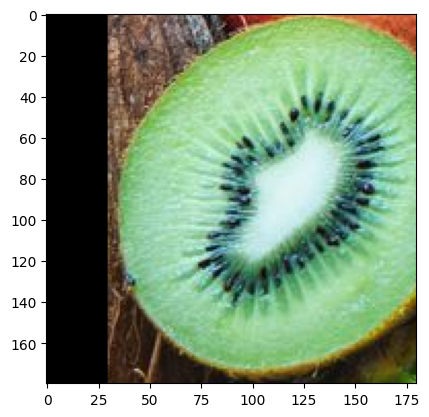

In [2]:
# BT1 Chọn quả kiwi tịnh tiến kiwi sang phải 30px
import numpy as np
import imageio.v2 as iio
import matplotlib.pylab as plt
import scipy.ndimage as nd

data = iio.imread('./exercise/colorful-ripe-tropical-fruits.jpg')
# Chọn quả kiwi
kiwi = data[920:1100, 390:570]
print(data.shape)
# Tịnh tiến quả kiwi
bdata = nd.shift(kiwi, (0, 30, 0))

# Lưu ảnh kết quả
iio.imsave('kiwi.jpg', bdata)

plt.imshow(bdata)
plt.show()

(1414, 2119, 3)


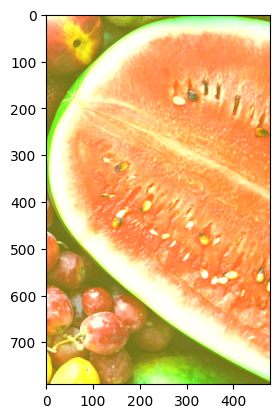

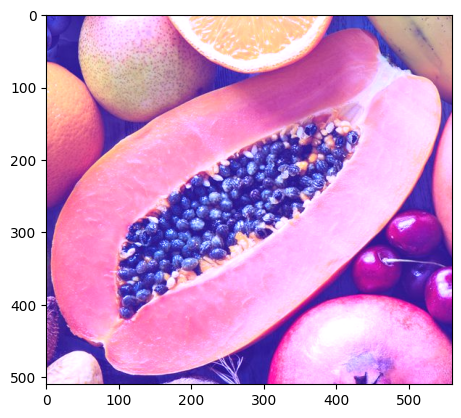

In [ ]:
# BT2 Chọn quả đu đủ và dưa hấu, đổi màu hai đối tượng
import numpy as np
import imageio.v2 as iio
import matplotlib.pylab as plt
import scipy.ndimage as nd

# Đọc ảnh
data = iio.imread('./exercise/colorful-ripe-tropical-fruits.jpg')
print(data.shape)

# Chọn các đối tượng
dudu = data[310:820, 120:680].copy()  # Đu đủ
duahau = data[310:1100, 1640:2119].copy()  # Dưa hấu

# Function to change color
def change_color(image, color_shift):
    # Convert to float for manipulation
    image_float = image.astype(float)
    # Apply color shift
    image_float += color_shift
    # Clip values to stay within valid range
    image_float = np.clip(image_float, 0, 255)
    return image_float.astype(np.uint8)

# Thay đổi màu
dudu_colored = change_color(dudu, np.array([30, 10, 130]))
duahau_colored = change_color(duahau, np.array([100, 100, 10]))

# Lưu ảnh
iio.imsave('dudu.jpg', dudu_colored)
iio.imsave('duahau.jpg', duahau_colored)

# Hiển thị hình ảnh
plt.imshow(duahau_colored)
plt.show()
plt.imshow(dudu_colored)
plt.show()

(605, 1021, 3)


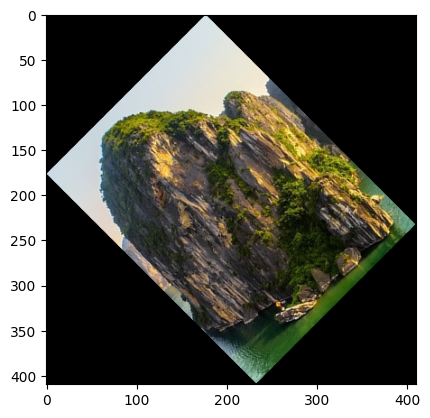

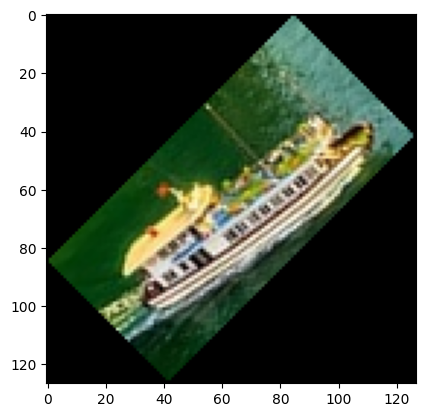

In [4]:
# BT3 Chọn ngọn núi và con thuyền xoay 1 gốc 45 độ
import numpy as np
import imageio.v2 as iio
import matplotlib.pylab as plt
import scipy.ndimage as nd

# Đọc ảnh
data = iio.imread('./exercise/quang_ninh.jpg')
print(data.shape)

# Cắt ảnh núi và thuyền
nui = data[10:340, 420:670]
thuyen = data[340:400, 550:670]

# Xoay cả hai đối tượng 45 độ
nui_rotated = nd.rotate(nui, 45)
thuyen_rotated = nd.rotate(thuyen, 45)

# Lưu ảnh
iio.imsave('nui_rotated.jpg', nui_rotated)
iio.imsave('thuyen_rotated.jpg', thuyen_rotated)

plt.imshow(nui_rotated)
plt.show()
plt.imshow(thuyen_rotated)
plt.show()


(348, 600, 3)


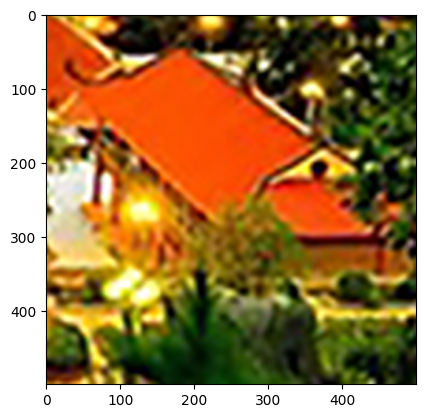

In [6]:
# BT4 Chọn ngôi chùa và tăng kích thước lên gấp 5 lần
import numpy as np
import imageio.v2 as iio
import matplotlib.pylab as plt
import scipy.ndimage as nd

# Đọc ảnh
data = iio.imread('./exercise/pagoda.jpg')
print(data.shape)

# Cắt ảnh ngôi chùa
chua = data[180:280, 400:500]

# Phóng to ngôi chùa lên 5 lần
chua_zoomed = nd.zoom(chua, (5, 5, 1))

# Lưu ảnh
iio.imsave('chua_zoomed.jpg', chua_zoomed)

# Hiển thị ảnh
plt.imshow(chua_zoomed)
plt.show()

Chọn một hình trong các hình sau:
1: colorful-ripe-tropical-fruits.jpg
2: ha-long-bay-in-vietnam.jpg
3: pagoda.jpg
4: quang_ninh.jpg

---
Menu:
T: Tịnh tiến
X: Xoay
P: Phóng to
H: Thu nhỏ
C: Coordinate Map
E: Thoát
---


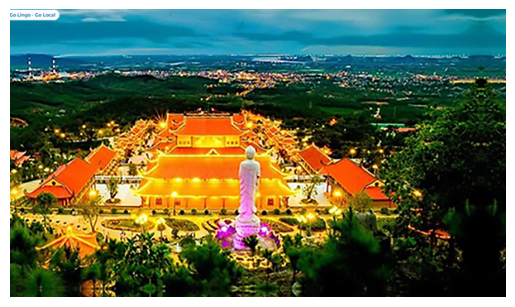


---
Menu:
T: Tịnh tiến
X: Xoay
P: Phóng to
H: Thu nhỏ
C: Coordinate Map
E: Thoát
---


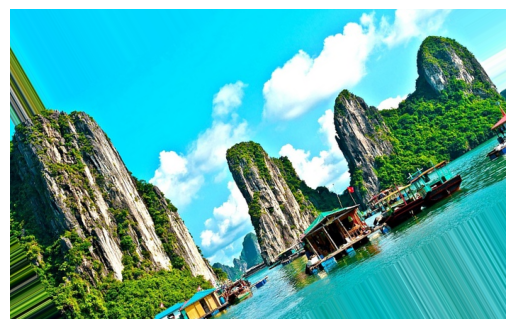


---
Menu:
T: Tịnh tiến
X: Xoay
P: Phóng to
H: Thu nhỏ
C: Coordinate Map
E: Thoát
---


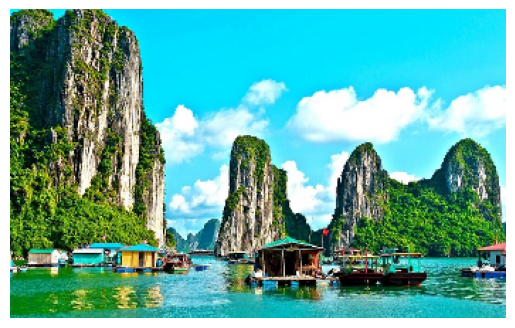


---
Menu:
T: Tịnh tiến
X: Xoay
P: Phóng to
H: Thu nhỏ
C: Coordinate Map
E: Thoát
---


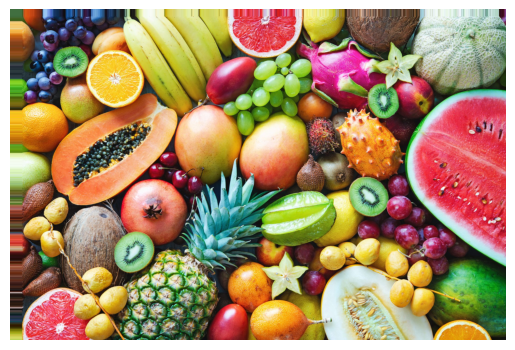


---
Menu:
T: Tịnh tiến
X: Xoay
P: Phóng to
H: Thu nhỏ
C: Coordinate Map
E: Thoát
---
Đang thoát chương trình.


In [ ]:
# BT5 Viết chương trình tạo menu tịnh tuyến, xoay, phóng to, thu nhỏ, coordinate map
# Khi chọn phím T, X, P, H, C thì hỏi muốn chọn hình nào trong thư mục exercise.
# Khi người dùng chọn hình nào thì thực hiện biến đổi trên hình đó
import numpy as np
import imageio.v2 as iio
import matplotlib.pylab as plt
import scipy.ndimage as nd
import os

def load_images(directory):
    """Load images from the specified directory."""
    images = {}
    for filename in os.listdir(directory):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')): # Added .lower() for robustness
            images[filename] = iio.imread(os.path.join(directory, filename))
    return images

def display_image(image):
    """Display the image using matplotlib."""
    plt.imshow(image)
    plt.axis('off')  # Hide axis
    plt.show()

def translate_image(image, tx, ty):
    # For color images, shift across all channels
    if image.ndim == 3:
        return nd.shift(image, shift=(ty, tx, 0), mode='nearest')
    return nd.shift(image, shift=(ty, tx), mode='nearest')

def rotate_image(image, angle):
    """Rotate the image by the specified angle."""
    # For color images, rotate across all channels
    if image.ndim == 3:
        return nd.rotate(image, angle, reshape=False, mode='nearest') # reshape=False to keep dimensions
    return nd.rotate(image, angle, mode='nearest')

def zoom_image(image, zoom_factor):
    """Zoom in or out of the image."""
    # For color images, zoom across all channels
    if image.ndim == 3:
        return nd.zoom(image, (zoom_factor, zoom_factor, 1), mode='nearest') # Zoom x, y, but not channels
    return nd.zoom(image, zoom_factor, mode='nearest')

def coordinate_map(image, shift_x, shift_y):
    """Apply coordinate mapping to the image."""
    if image.ndim == 3: # Handle color images
        transformed_channels = []
        for i in range(image.shape[2]):
            coords = np.indices(image.shape[:2]).astype(float) # Convert to float here
            coords[0] += shift_y
            coords[1] += shift_x
            transformed_channels.append(nd.map_coordinates(image[:,:,i], coords, order=1, mode='reflect'))
        return np.stack(transformed_channels, axis=-1)
    else: # Handle grayscale images
        coords = np.indices(image.shape[:2]).astype(float) # Convert to float here
        coords[0] += shift_y
        coords[1] += shift_x
        return nd.map_coordinates(image, coords, order=1, mode='reflect')

def main():
    directory = './exercise'

    # Check if the directory exists
    if not os.path.exists(directory):
        print(f"Thư mục '{directory}' không tồn tại. Vui lòng tạo thư mục này và thêm hình ảnh vào.")
        return

    images = load_images(directory)

    if not images:
        print("Không tìm thấy hình ảnh nào trong thư mục đã chỉ định.")
        return

    print("Chọn một hình trong các hình sau:")
    # Using sorted(images.keys()) to display images in a consistent order
    image_filenames = sorted(images.keys())
    for idx, filename in enumerate(image_filenames):
        print(f"{idx + 1}: {filename}")

    while True:
        print("\n---")
        print("Menu:")
        print("T: Tịnh tiến")
        print("X: Xoay")
        print("P: Phóng to")
        print("H: Thu nhỏ")
        print("C: Coordinate Map")
        print("E: Thoát")
        print("---")
        
        choice = input("Chọn một tùy chọn (T/X/P/H/C/E): ").strip().upper()

        if choice == 'E':
            print("Đang thoát chương trình.")
            break

        image_choice = input("Nhập số ID của hình ảnh bạn muốn biến đổi: ")
        try:
            image_index = int(image_choice) - 1
            if image_index < 0 or image_index >= len(image_filenames): # Use image_filenames for indexing
                print("Lựa chọn hình ảnh không hợp lệ. Vui lòng thử lại.")
                continue
            selected_image_filename = image_filenames[image_index]
            selected_image = images[selected_image_filename]
        except ValueError:
            print("Vui lòng nhập một số hợp lệ cho lựa chọn hình ảnh.")
            continue

        if choice == 'T':
            try:
                x_direction = float(input("Nhập dịch chuyển theo trục x (ví dụ: 50): "))
                y_direction = float(input("Nhập dịch chuyển theo trục y (ví dụ: 30): "))
                transformed_image = translate_image(selected_image, x_direction, y_direction)
                display_image(transformed_image)
            except ValueError:
                print("Dịch chuyển không hợp lệ. Vui lòng nhập một số.")

        elif choice == 'X':
            try:
                angle = float(input("Nhập góc xoay (độ, ví dụ: 45): "))
                transformed_image = rotate_image(selected_image, angle)
                display_image(transformed_image)
            except ValueError:
                print("Góc xoay không hợp lệ. Vui lòng nhập một số.")

        elif choice == 'P':
            try:
                zoom_factor = float(input("Nhập hệ số phóng to (ví dụ: 1.5 cho 150%): "))
                if zoom_factor <= 0:
                    print("Hệ số phóng to phải lớn hơn 0.")
                    continue
                transformed_image = zoom_image(selected_image, zoom_factor)
                display_image(transformed_image)
            except ValueError:
                print("Hệ số phóng to không hợp lệ. Vui lòng nhập một số.")

        elif choice == 'H':
            try:
                zoom_factor = float(input("Nhập hệ số thu nhỏ (ví dụ: 0.5 cho 50%): "))
                if zoom_factor <= 0 or zoom_factor >= 1:
                    print("Hệ số thu nhỏ phải lớn hơn 0 và nhỏ hơn 1.")
                    continue
                transformed_image = zoom_image(selected_image, zoom_factor)
                display_image(transformed_image)
            except ValueError:
                print("Hệ số thu nhỏ không hợp lệ. Vui lòng nhập một số.")

        elif choice == 'C':
            try:
                shift_x = float(input("Nhập dịch chuyển cho map tọa độ theo trục x (ví dụ: 20): "))
                shift_y = float(input("Nhập dịch chuyển cho map tọa độ theo trục y (ví dụ: 10): "))
                transformed_image = coordinate_map(selected_image, shift_x, shift_y)
                display_image(transformed_image)
            except ValueError:
                print("Dịch chuyển cho map tọa độ không hợp lệ. Vui lòng nhập một số.")

        else:
            print("Tùy chọn không hợp lệ. Vui lòng thử lại.")

if __name__ == "__main__":
    main()